In [2]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load cleaned data
df = pd.read_csv("../day02-python-problems/cleaned_titanic.csv")

# Define features and target
features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone"]
X = df[features]
y = df["Survived"]

# Scale features (only for logistic regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr_scores = cross_val_score(lr, X_scaled, y, cv=5)
print("Logistic Regression CV Accuracies:", np.round(lr_scores * 100, 2))
print("Mean Accuracy:", round(lr_scores.mean() * 100, 2), "%")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X, y, cv=5)
print("\nRandom Forest CV Accuracies:", np.round(rf_scores * 100, 2))
print("Mean Accuracy:", round(rf_scores.mean() * 100, 2), "%")


Logistic Regression CV Accuracies: [77.09 79.21 79.78 79.78 82.02]
Mean Accuracy: 79.58 %

Random Forest CV Accuracies: [75.98 82.02 86.52 78.09 82.02]
Mean Accuracy: 80.93 %


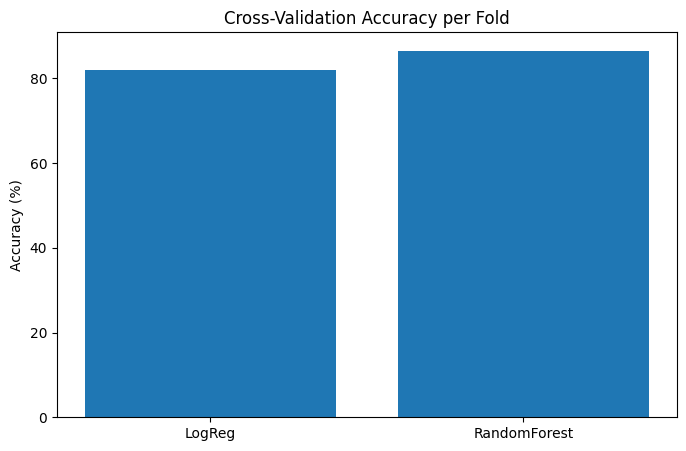

In [3]:
import matplotlib.pyplot as plt

models = ["LogReg"] * 5 + ["RandomForest"] * 5
scores = np.concatenate([lr_scores, rf_scores])

plt.figure(figsize=(8, 5))
plt.title("Cross-Validation Accuracy per Fold")
plt.bar(models, scores * 100)
plt.ylabel("Accuracy (%)")
plt.show()
